In [56]:
import cv2
import torch 
import matplotlib.pyplot as plt 
from torch.utils.data import DataLoader
from torchvision import transforms
from torchvision.datasets import ImageFolder
from torchvision.utils import draw_bounding_boxes
from torchvision.ops import box_iou, nms
from numpy import round

In [13]:
# random seed for reproducibility
torch.manual_seed(3)

## Dataset

In [18]:
# transform images
training_transforms = transforms.Compose([transforms.ToTensor(), transforms.Resize((244,244))])
# loading dataset and applying transformations
train_data = ImageFolder(root='fruits-data/images', transform=training_transforms)
# train dataset loader
train_loader = DataLoader(dataset=train_data, batch_size=2, shuffle=True)

torch.Size([244, 244, 3])


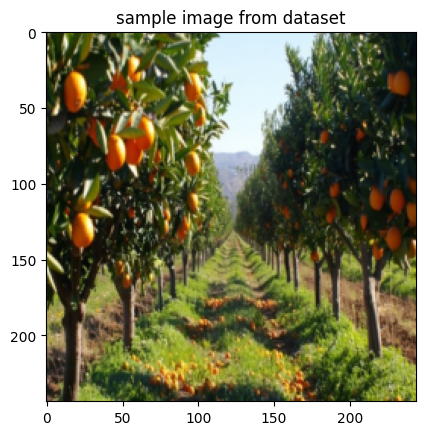

In [42]:
# visualizing data samples
images, image_label = next(iter(train_loader))
image = images[0] # remove batch size
image = image.permute(1,2,0) # height, width, channels
print(image.shape)
plt.title("sample image from dataset")
plt.imshow(image.clamp(0, 1))

## Bounding Boxes

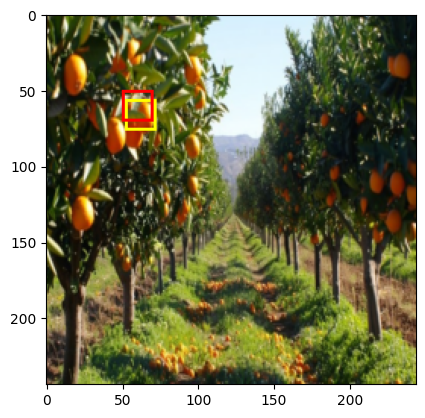

In [86]:
b1 = [52, 56, 52+20, 56+20] # yellow box
b2 = [50, 50, 50+20, 50+20] # red box

# convert image to uint8
image = images[0]
image_uint8 = (image * 255).to(torch.uint8)

# converting boxes to tensor
bb_tensors = torch.tensor([b1, b2]).float()

# drawing the boxes on sample image
draw_boxes = draw_bounding_boxes(image=image_uint8, boxes=bb_tensors, width=2, colors=['yellow', 'red'])

# convert to PIL image to visualize
image_transforms = transforms.ToPILImage()

image_with_boxes = image_transforms(draw_boxes)
plt.imshow(image_with_boxes)

## IOU

In [87]:
iou_score = box_iou(torch.tensor(b1).unsqueeze(0), torch.tensor(b2).unsqueeze(0))
print(f"iou: {iou_score}")

iou: tensor([[0.4599]])


## NonMax Suppression

In [ ]:
# boxes confidence scores
bb_scores = torch.tensor([0.80, 0.70]) # [b1 score, b2 score]
# non max suppression
nms_best_box = nms(boxes=bb_tensors, scores=bb_scores, iou_threshold=0.45)
# keep one box
best_box = bb_tensors[nms_best_box]
# one with higher confidence score is kept
print(f"best box: {best_box}") # since b1 has higher score , it will be kept

best box: tensor([[52., 56., 72., 76.]])
